In [3]:
import numpy as np
import matplotlib.pyplot as plt

from CBSetup import *
from myutils import *
from simulator import *
from scipy.signal import find_peaks
import tqdm as tqdm

We can now build the setup for task 9 according to the CB.setup.pdf file. We set the parameters to a default value of:
- Gb = 50
- Gs = 1
- C = 1
- Cg = 0.01

In [5]:
def setuptask9(Gb=50, Gs=1, C=1, Cg=0.01):
    #First we create the setup
    #two leads
    Setup=CBSetup()
    Setup.add_lead('LeadLeft')
    Setup.add_lead('LeadRight')

    #two islands
    Setup.add_island('Island1')
    Setup.add_island('Island2')

    #We connect the leads to the islands with 3 tunnel junctions
    Setup.add_junctionBIL('Junction1','Island1','LeadLeft',Gb,C)
    Setup.add_junctionBTI('Junction2','Island1','Island2',Gb,C)
    Setup.add_junctionBIL('Junction3','Island2','LeadRight',Gs,C)

    #We add gates to the islands
    Setup.add_gate('Gate_1', 'Island1', Cg)
    Setup.add_gate('Gate_2', 'Island2', Cg)

    Setup.finish()

    return Setup

## a)
We can now do exercise a). We set the temperature T = 10e-3 and the gate voltages Volt_Gate_1 = 0 and Volt_Gate_2 = 0. 
We run the voltage difference between the leads from 0 to Vmax in Numsteps steps during the simulation. We can then plot the I-V curve for this setup, varying Gb = 50,100,200 en 400.

In [43]:
Numsteps = 100
Vmax = 5
timeinterval = 25000
zeros = np.zeros(2)
currents = []
voltages = np.linspace(0, Vmax, Numsteps + 1)
Gb_values = [50, 100, 200, 400]
for Gb in Gb_values:
    Setup = setuptask9(Gb=Gb)
    Setup.temperature = 10e-3
    #initialize the system with zero voltages and zero charges
    Setup.set_gate_voltage('Gate_1', 0)
    Setup.set_gate_voltage('Gate_2', 0)
    Setup.set_lead_voltage('LeadLeft', 0)
    Setup.set_lead_voltage('LeadRight', 0)

    runcurrents = Setup.runit(
        Numsteps,
        zeros,
        zeros,
        np.array([Vmax / 2, -Vmax / 2]),
        zeros,
        timeinterval=timeinterval,
        debug=True,
    )
    currents.append(np.array(runcurrents)[:,0]) #I am only interested in the current through the left lead, which is the first column of runcurrents

currents = np.array(currents)
print(currents)
print(currents.shape)

Run 1
CPU time: 0.0 Simulated time: 100041172122.8 Events: 1 Cache: 1
Run 2
CPU time: 0.0 Simulated time: 1731748022383.8 Events: 2 Cache: 2
Run 3
CPU time: 0.0 Simulated time: 674054973258.0 Events: 2 Cache: 2
Run 4
CPU time: 0.0 Simulated time: 12215414421.0 Events: 2 Cache: 2
Run 5
CPU time: 0.0 Simulated time: 8782284882.6 Events: 2 Cache: 2
Run 6
CPU time: 0.0 Simulated time: 2308558634.1 Events: 3 Cache: 3
Run 7
CPU time: 0.0 Simulated time: 35616426.3 Events: 3 Cache: 3
Run 8
CPU time: 0.0 Simulated time: 98199955.9 Events: 3 Cache: 3
Run 9
CPU time: 0.0 Simulated time: 8621767.0 Events: 2 Cache: 2
Run 10
CPU time: 0.0 Simulated time: 3211447.7 Events: 2 Cache: 2
Run 11
CPU time: 0.0 Simulated time: 38531.4 Events: 3 Cache: 3
Run 12
CPU time: 0.0 Simulated time: 141890.6 Events: 2 Cache: 2
Run 13
CPU time: 0.0 Simulated time: 88774.4 Events: 3 Cache: 3
Run 14
CPU time: 0.0 Simulated time: 35984.3 Events: 4 Cache: 2
Run 15
CPU time: 0.0 Simulated time: 28770.2 Events: 31 Cache: 4

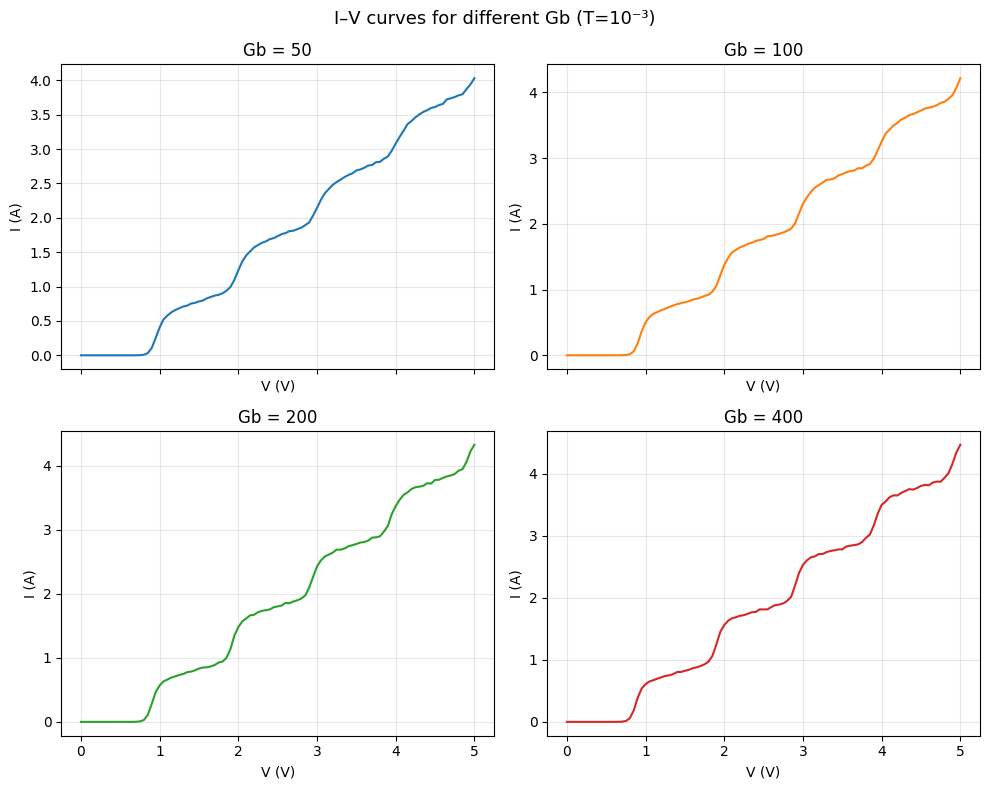

In [44]:
# --- Plot all four I–V curves together ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=False)
axes = axes.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for idx, Gb in enumerate(Gb_values):
    ax = axes[idx]
    ax.plot(voltages, currents[idx], color=colors[idx], lw=1.5)
    ax.set_title(f'Gb = {Gb}')
    ax.set_xlabel('V (V)')
    ax.set_ylabel('I (A)')
    ax.grid(True, alpha=0.3)

fig.suptitle('I–V curves for different Gb (T=10⁻³)', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# --- Differential conductance dI/dV and step analysis ---
dV = voltages[1] - voltages[0]

print('=' * 65)
print(f'{"Gb":>6}  {"Step":>5}  {"V_step":>8}  {"G_high (dI/dV)":>16}')
print('=' * 65)

high_conductances = {}   # Gb -> list of (V_step, G_high)

for idx, Gb in enumerate(Gb_values):
    I = currents[idx]
    dIdV = np.diff(I) / dV
    V_mid = 0.5 * (voltages[:-1] + voltages[1:])

    # Find local peaks in dI/dV (= high-conductance cusps)
    # prominence filter to avoid noise spikes
    peaks, props = find_peaks(dIdV, prominence=0.5*dIdV.max(), distance=5)

    high_conductances[Gb] = [(V_mid[p], dIdV[p]) for p in peaks]

    for step_idx, p in enumerate(peaks):
        print(f'{Gb:>6}  {step_idx+1:>5}  {V_mid[p]:>8.4f}  {dIdV[p]:>16.6f}')

print('=' * 65)
print('\n Observation: step positions (V_step) do NOT change with Gb (only very slightly, explained by numerical inaccuracies).')


    Gb   Step    V_step    G_high (dI/dV)
    50      1    0.9750          3.053656
    50      2    1.9750          2.799904
    50      3    3.0250          2.380272
    50      4    3.9750          2.063139
   100      1    0.9250          3.634199
   100      2    1.9250          3.176747
   100      3    2.9250          3.008845
   100      4    3.9750          2.624723
   200      1    0.9250          3.610862
   200      2    1.9250          4.211403
   200      3    2.9250          3.374910
   200      4    3.9250          3.711061
   400      1    0.8750          4.086437
   400      2    1.9250          4.056662
   400      3    2.9250          4.010672
   400      4    3.9250          3.798476

 Observation: step positions (V_step) do NOT change with Gb (only very slightly, explained by numerical inaccuracies).


In [51]:
print('Scaling of high conductance with Gb:')
print()

# Numerical check: ratio G_high(2*Gb) / G_high(Gb) for step 1
for i in range(4):
    print("="*65)
    print(f'Checking scaling for step {i+1}:')
    ratio_100_50  = high_conductances[100][i][1] / high_conductances[50][i][1]
    ratio_200_100 = high_conductances[200][i][1] / high_conductances[100][i][1]
    ratio_400_200 = high_conductances[400][i][1] / high_conductances[200][i][1]
    print(f'  G_high(100)/G_high(50)  = {ratio_100_50:.3f} ')
    print(f'  G_high(200)/G_high(100) = {ratio_200_100:.3f} ')
    print(f'  G_high(400)/G_high(200) = {ratio_400_200:.3f} ')
print("="*65)


Scaling of high conductance with Gb:

Checking scaling for step 1:
  G_high(100)/G_high(50)  = 1.190 
  G_high(200)/G_high(100) = 0.994 
  G_high(400)/G_high(200) = 1.132 
Checking scaling for step 2:
  G_high(100)/G_high(50)  = 1.135 
  G_high(200)/G_high(100) = 1.326 
  G_high(400)/G_high(200) = 0.963 
Checking scaling for step 3:
  G_high(100)/G_high(50)  = 1.264 
  G_high(200)/G_high(100) = 1.122 
  G_high(400)/G_high(200) = 1.188 
Checking scaling for step 4:
  G_high(100)/G_high(50)  = 1.272 
  G_high(200)/G_high(100) = 1.414 
  G_high(400)/G_high(200) = 1.024 


## b) Dependence on induced charge q₂

We fix Gb = 100, Gs = 1, and scan q₂ ∈ (−0.5, 0.5) with q₁ = 0 (and
separately q₁ = 0.5).  For each q₂ we determine the step position,
high conductance and low conductance for steps 1, 2, and 3.

In [42]:
def run_iv_curve(Gb=100, Gs=1, C=1, Cg=0.01,
                 q1=0.0, q2=0.0, T=1e-3,
                 Vmax=5.0, Numsteps=100, timeinterval=1000):
    """Run a full I-V sweep and return (voltages, currents)."""
    zeros = np.zeros(2)
    # Convert induced charge -> gate voltage: V_g = q / Cg
    Vg1 = q1 / Cg
    Vg2 = q2 / Cg
    Setup = setuptask9(Gb=Gb, Gs=Gs, C=C, Cg=Cg)
    Setup.set_gate_voltage('Gate_1', Vg1)
    Setup.set_gate_voltage('Gate_2', Vg2)
    Setup.temperature = T
    Setup.set_lead_voltage('LeadLeft',  0)
    Setup.set_lead_voltage('LeadRight', 0)

    runcurrents = Setup.runit(
        Numsteps, zeros, zeros,
        np.array([Vmax/2, -Vmax/2]), zeros,
        timeinterval=timeinterval, debug=False,
    )
    I = np.array(runcurrents)[:, 0]
    V = np.linspace(0, Vmax, Numsteps + 1)
    return V, I


def extract_step_properties(V, I, n_steps=3):
    """
    Return lists of (V_step, G_high, G_low) for up to n_steps steps.
    G_high = local peak of dI/dV just at the step start.
    G_low  = dI/dV in the plateau just before the next step.
    """
    dV   = V[1] - V[0]
    dIdV = np.diff(I,n=1) / dV
    averaged_dIdV = np.convolve(dIdV, np.ones(5)/5, mode='valid')  # Simple moving average to smooth noise
    
    V_m  = 0.5 * (V[:-1] + V[1:])
    
    peaks, _ = find_peaks(averaged_dIdV, prominence=0.6 * averaged_dIdV.max(), distance=10)

    # plt.figure(figsize=(8,4))
    # plt.plot(np.linspace(V[0], V[-1], len(averaged_dIdV)), averaged_dIdV, label='dI/dV')
    # plt.scatter(np.linspace(V[0], V[-1], len(averaged_dIdV))[peaks], averaged_dIdV[peaks], color='red', label='Peaks')
    # plt.xlabel('Voltage (V)')
    # plt.ylabel('dI/dV (S)')
    # plt.title('Differential Conductance with Detected Peaks')
    # plt.legend()
    # plt.show()

    results = []
    for k, p in enumerate(peaks[:n_steps]):
        V_step = V_m[p]
        G_high = averaged_dIdV[p]

        # Low conductance = minimum of dI/dV in [V_step, next_V_step)
        if k + 1 < len(peaks):
            next_p = peaks[k + 1]
        else:
            next_p = len(averaged_dIdV)
        plateau = averaged_dIdV[p:next_p]
        G_low = plateau.min() if len(plateau) > 0 else np.nan

        results.append((V_step, G_high, G_low))

    # Pad with NaN if fewer steps found
    while len(results) < n_steps:
        results.append((np.nan, np.nan, np.nan))

    return results

In [43]:
# --- Scan q2 for q1=0 and q1=0.5 ---
q2_values = np.linspace(-0.49, 0.49, 35)   # 35 points, avoid exactly ±0.5

results_b = {}   # (q1_label) -> array of shape (len(q2), 3, 3)
                 # dimensions: [q2_idx, step_idx, property_idx=(V,G_high,G_low)]

for q1_val, label in [(0.0, 'q1=0'), (0.5, 'q1=0.5')]:
    data = np.full((len(q2_values), 3, 3), np.nan)
    for i in tqdm.tqdm(range(len(q2_values)), desc=f'Scanning q2 for {label}'):
        q2 = q2_values[i]
        V, I = run_iv_curve(q1=q1_val, q2=q2, Numsteps=100, timeinterval=1000)
        if i == 0: 
                print(f'Example I-V curve for {label} at q2={q2:.3f}:')
                # plt.plot(V, I, label=f'q2={q2:.3f}')
                # plt.xlabel('V (V)')
                # plt.ylabel('I (A)')
                # plt.title(f'I-V curve for {label} at q2={q2:.3f}')
                # plt.grid(True)
                # plt.legend()
                # plt.show()
        steps = extract_step_properties(V, I, n_steps=3)
        for s, (Vstep, Ghigh, Glow) in enumerate(steps):
            data[i, s, 0] = Vstep
            data[i, s, 1] = Ghigh
            data[i, s, 2] = Glow
        if i ==0:
            print(f'Extracted step properties for {label} at q2={q2:.3f}:')
            for s, (Vstep, Ghigh, Glow) in enumerate(steps):
                print(f'  Step {s+1}: V_step={Vstep:.4f} V, G_high={Ghigh:.6f} S, G_low={Glow:.6f} S')
        # print(f'Extracted step properties for {label} at q2={q2:.3f}:')
        # for s, (Vstep, Ghigh, Glow) in enumerate(steps):
        #     print(f'  Step {s+1}: V_step={Vstep:.4f} V, G_high={Ghigh:.6f} S, G_low={Glow:.6f} S')
        
    results_b[label] = data

print('Part (b) data collection complete.')

Scanning q2 for q1=0:   3%|▎         | 1/35 [00:04<02:17,  4.04s/it]

Example I-V curve for q1=0 at q2=-0.490:
Extracted step properties for q1=0 at q2=-0.490:
  Step 1: V_step=0.9250 V, G_high=2.824382 S, G_low=0.114304 S
  Step 2: V_step=1.9250 V, G_high=2.826454 S, G_low=-0.017511 S
  Step 3: V_step=2.9750 V, G_high=2.794158 S, G_low=0.071069 S


Scanning q2 for q1=0.5:   3%|▎         | 1/35 [00:04<02:19,  4.09s/it]

Example I-V curve for q1=0.5 at q2=-0.490:
Extracted step properties for q1=0.5 at q2=-0.490:
  Step 1: V_step=0.9250 V, G_high=2.807344 S, G_low=0.128299 S
  Step 2: V_step=1.9250 V, G_high=2.840030 S, G_low=-0.340255 S
  Step 3: V_step=2.9750 V, G_high=2.917220 S, G_low=0.002880 S


Scanning q2 for q1=0.5: 100%|██████████| 35/35 [02:22<00:00,  4.07s/it]

Part (b) data collection complete.


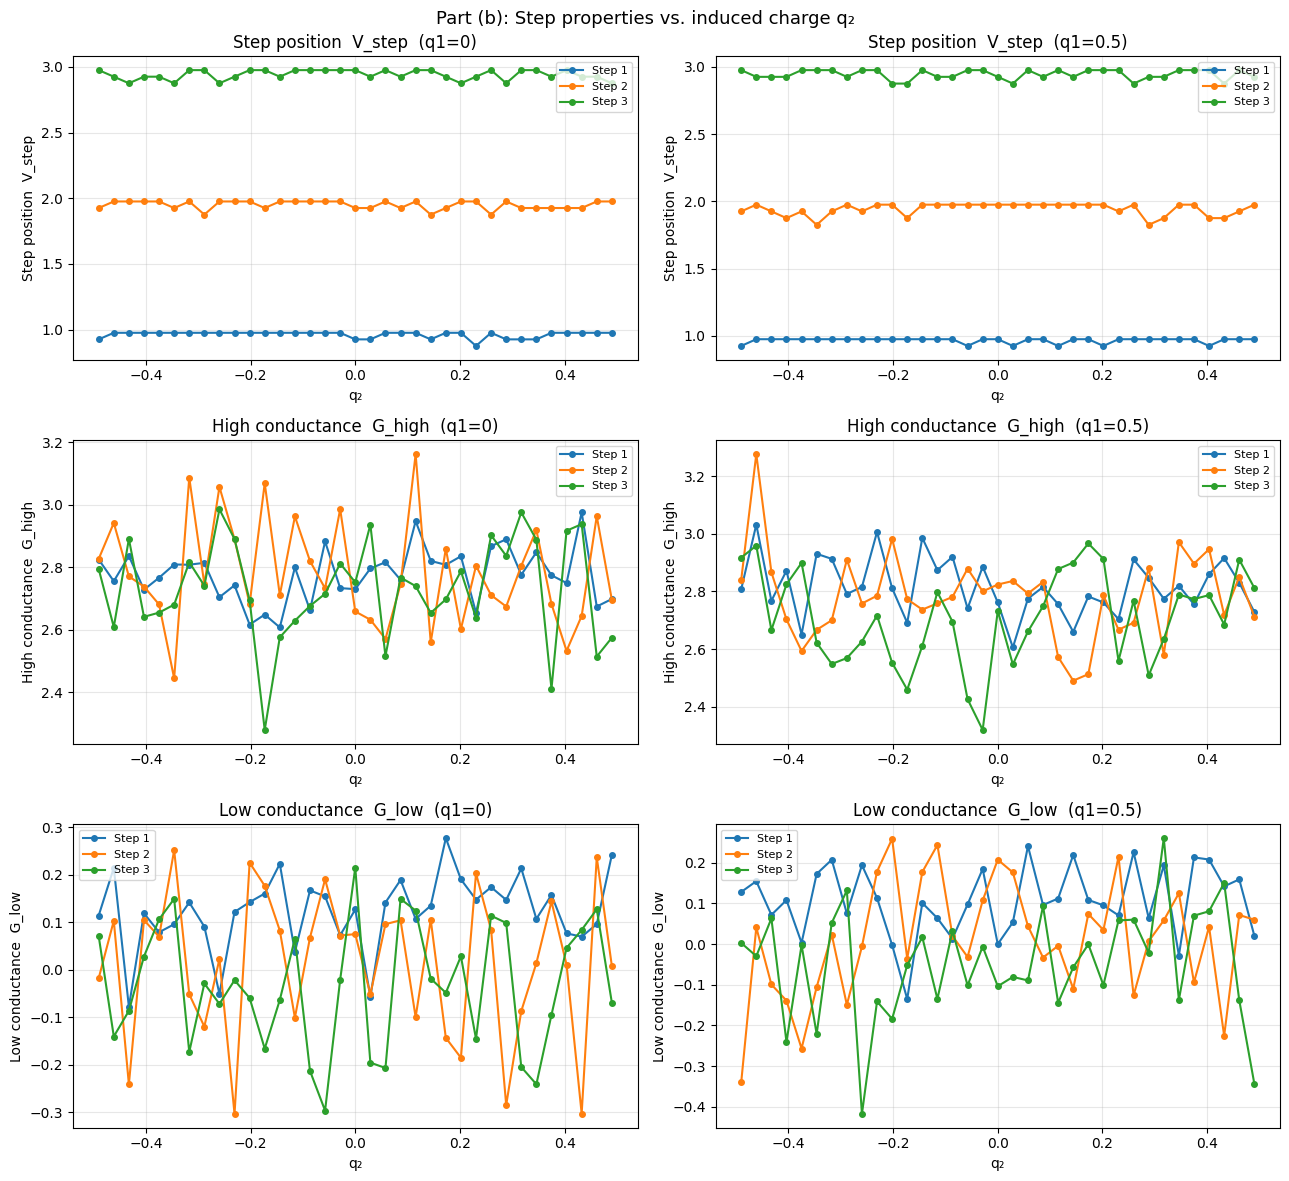

In [44]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
step_colors = ['tab:blue', 'tab:orange', 'tab:green']
step_labels = ['Step 1', 'Step 2', 'Step 3']
q1_labels   = ['q1=0', 'q1=0.5']

row_titles = ['Step position  V_step', 'High conductance  G_high', 'Low conductance  G_low']

for col, label in enumerate(q1_labels):
    data = results_b[label]
    for row, prop_name in enumerate(row_titles):
        ax = axes[row, col]
        for s in range(3):
            y = data[:, s, row]
            mask = ~np.isnan(y)
            ax.plot(q2_values[mask], y[mask],
                    color=step_colors[s], marker='o', ms=4,
                    label=step_labels[s])
        ax.set_xlabel('q₂')
        ax.set_ylabel(prop_name)
        ax.set_title(f'{prop_name}  ({label})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('Part (b): Step properties vs. induced charge q₂', fontsize=13)
plt.tight_layout()
plt.show()

## c) Temperature dependence of the I–V curve

We set Gb = 100, q₁ = q₂ = 0 and compute 10 temperatures in
T $\in (10^{-4}, 10^{-2})$. 

In [47]:
T_values = np.logspace(-4, -2, 12)   # 12 temperatures

# Voltage range: slightly wider than the first step to capture rounding
Vmax_c   = 5.0
Numsteps_c = 100
timeinterval_c = 1000
V_c = np.linspace(0, Vmax_c, Numsteps_c + 1)

currents_c = {}   # T -> current array

for T_val in tqdm.tqdm(T_values):
    V_tmp, I_tmp = run_iv_curve(Gb=100, q1=0, q2=0, T=T_val,
                                Vmax=Vmax_c, Numsteps=Numsteps_c,
                                timeinterval=timeinterval_c)
    currents_c[T_val] = I_tmp

print('Part (c) data collection complete.')

100%|██████████| 12/12 [00:48<00:00,  4.08s/it]

Part (c) data collection complete.
